# Gradient Boosting for Classification
### Gradient Descent in Function Space — Every Step Visualised

Built from scratch so every split, every leaf value, and every residual update is visible.
A tiny 12-sample dataset keeps the trees readable at a glance; we then scale to 2-D to watch the decision boundary grow.


## 0 · Imports & Helpers

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_classification
import warnings; warnings.filterwarnings("ignore")

np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

C = dict(cls0="steelblue", cls1="tomato", pred="mediumseagreen",
         logodds="darkorange", tree="navy")


def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def log_loss_val(y, F):
    p = np.clip(sigmoid(F), 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def newton_leaf_values(tree, X, y, p):
    leaf_ids   = tree.apply(X)
    leaf_gamma = np.zeros(tree.tree_.node_count)
    for leaf in np.unique(leaf_ids):
        mask  = leaf_ids == leaf
        g_sum = np.sum(y[mask] - p[mask])
        h_sum = np.sum(p[mask] * (1 - p[mask]))
        leaf_gamma[leaf] = g_sum / (h_sum + 1e-8)
    return leaf_ids, leaf_gamma

def fit_gbc(X, y, n_estimators=5, learning_rate=0.5, max_depth=2, verbose=True):
    y_bar = y.mean()
    F0v   = np.log(y_bar / (1 - y_bar))
    F     = np.full(len(y), F0v)
    history, trees = [], []
    for m in range(1, n_estimators + 1):
        p         = sigmoid(F)
        residuals = y - p
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
        tree.fit(X, residuals)
        leaf_ids, leaf_gamma = newton_leaf_values(tree, X, y, p)
        F = F + learning_rate * leaf_gamma[leaf_ids]
        history.append({
            "round": m, "tree": tree,
            "residuals": residuals.copy(), "p": p.copy(), "F": F.copy(),
            "loss": log_loss_val(y, F),
            "leaf_ids": leaf_ids.copy(), "leaf_gamma": leaf_gamma.copy(),
        })
        trees.append((tree, leaf_gamma))
        if verbose:
            acc = ((sigmoid(F) >= 0.5) == y.astype(bool)).mean()
            print(f"Round {m:2d}  |  log-loss = {history[-1]['loss']:.5f}  |  acc = {acc:.3f}")
    return F0v, trees, history

def predict_ensemble(F0v, trees, X_new, lr):
    F = np.full(len(X_new), F0v)
    for tree, leaf_gamma in trees:
        F += lr * leaf_gamma[tree.apply(X_new)]
    return sigmoid(F)

print("Imports & helpers OK ✓")

Imports & helpers OK ✓


## 1 · The Big Idea: Gradient Descent in Function Space

---

Ordinary gradient descent nudges **model weights** $\mathbf{w}$ downhill:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_{\mathbf{w}} \mathcal{L}$$

Gradient boosting does the same thing, but the "weights" are the model's **output values** at every training point — the prediction vector $\mathbf{F} = [F(x_1), \ldots, F(x_n)] \in \mathbb{R}^n$.

> **Analogy:** Imagine navigating a mountain (loss surface) not by adjusting a compass bearing (weights), but by asking a small guide — a decision tree — "which direction is downhill from where I stand?" Then you take a small step in that direction and ask again.

Because we need a function that *generalises* (not just values at training points), we approximate the negative gradient by fitting a regression tree to it, then add that tree to the ensemble.

| Classical gradient descent | Gradient boosting |
|---|---|
| Space: weights $\mathbf{w} \in \mathbb{R}^d$ | Space: function values $F(\cdot)$ |
| Step direction: $-\nabla_\mathbf{w}\mathcal{L}$ | Step direction: fitted tree $h_m \approx -\nabla \mathcal{L}$ |
| Update: $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla \mathcal{L}$ | Update: $F_m \leftarrow F_{m-1} + \eta\, h_m$ |
| Single differentiable model | Additive ensemble of trees |


## 2 · The Math: Log-Odds, Sigmoid, and Log Loss

---

### Why log-odds space?

We predict a scalar **log-odds score** $F(x)$ (unbounded: $-\infty$ to $+\infty$) and convert it to a probability through the **sigmoid**:

$$p = \sigma(F) = \frac{1}{1 + e^{-F}}$$

> **Intuition:** $F$ is a balance scale. $F=0$ means perfectly uncertain ($p=0.5$). Positive $F$ tips toward class 1; negative $F$ tips toward class 0.

### The loss function

For binary labels $y \in \{0,1\}$, log loss is:

$$\mathcal{L}(y, F) = -yF + \log(1 + e^F)$$

> **Intuition:** When $y=1$ and $F$ is very negative (predicting wrong confidently), $-F$ becomes large — the penalty blows up. The loss is asymmetric: confident correct predictions cost almost nothing; confident mistakes cost a lot.

### The pseudo-residual = negative gradient

Differentiate $\mathcal{L}$ with respect to the **prediction** $F$ (not a weight):

$$\frac{\partial \mathcal{L}}{\partial F} = \sigma(F) - y = p - y$$

So the negative gradient — the direction that decreases loss — is:

$$r_i = -\frac{\partial \mathcal{L}}{\partial F(x_i)} = y_i - p_i$$

> **Key insight:** The "thing each new tree must predict" is simply *how wrong you currently are*, in probability units. A true positive with $p=0.2$ has residual $+0.8$ — a loud signal to push the score up.

| Symbol | Meaning |
|--------|---------|
| $F_m(x)$ | Log-odds score after $m$ trees |
| $p_m = \sigma(F_m)$ | Predicted probability |
| $r_i = y_i - p_i$ | Pseudo-residual (negative gradient of log loss) |
| $\nu$ | Learning rate (shrinkage) |
| $\gamma_\ell$ | Leaf output value (Newton step) |


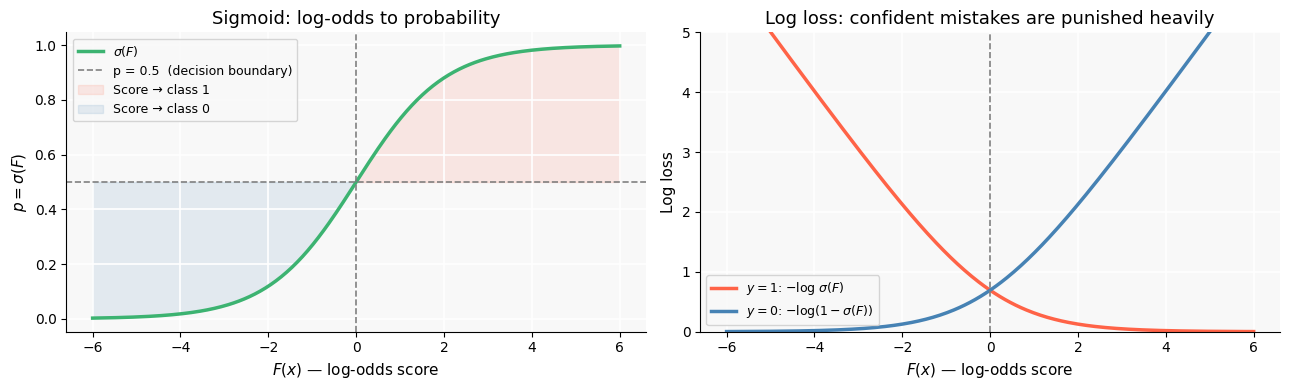

In [10]:
F_range = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- sigmoid ---
ax = axes[0]
ax.plot(F_range, sigmoid(F_range), color=C["pred"], lw=2.5, label=r"$\sigma(F)$")
ax.axhline(0.5, ls="--", color="grey", lw=1.2, label="p = 0.5  (decision boundary)")
ax.axvline(0,   ls="--", color="grey", lw=1.2)
ax.fill_between(F_range, sigmoid(F_range), 0.5, where=(F_range > 0),
                alpha=0.12, color=C["cls1"], label="Score → class 1")
ax.fill_between(F_range, sigmoid(F_range), 0.5, where=(F_range < 0),
                alpha=0.12, color=C["cls0"], label="Score → class 0")
ax.set_xlabel(r"$F(x)$ — log-odds score")
ax.set_ylabel(r"$p = \sigma(F)$")
ax.set_title("Sigmoid: log-odds to probability")
ax.legend(fontsize=9)

# --- log loss ---
ax2 = axes[1]
ax2.plot(F_range, -np.log(np.clip(sigmoid(F_range), 1e-15, 1)),
         color=C["cls1"], lw=2.5, label=r"$y=1$: $-\log\,\sigma(F)$")
ax2.plot(F_range, -np.log(np.clip(1 - sigmoid(F_range), 1e-15, 1)),
         color=C["cls0"], lw=2.5, label=r"$y=0$: $-\log(1-\sigma(F))$")
ax2.set_ylim(0, 5)
ax2.set_xlabel(r"$F(x)$ — log-odds score")
ax2.set_ylabel("Log loss")
ax2.set_title("Log loss: confident mistakes are punished heavily")
ax2.legend(fontsize=9)
ax2.axvline(0, ls="--", color="grey", lw=1.2)

plt.tight_layout()
plt.show()

## 3 · Toy Dataset — 12 Samples, 1 Feature

---

We use a tiny dataset deliberately: **small enough to fit entirely inside a decision-tree diagram**.
Feature: tumor size (cm). Label: 0 = benign, 1 = malignant.
Two samples near the boundary (x = 4.5 and x = 5.0) keep the problem interesting.


Samples: 12  |  class-1 (malignant): 5  |  class-0 (benign): 7


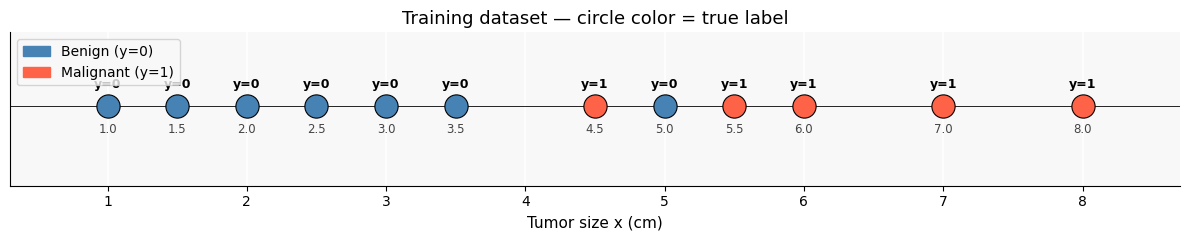

In [11]:
X = np.array([[1.0],[1.5],[2.0],[2.5],[3.0],[3.5],
               [4.5],[5.0],[5.5],[6.0],[7.0],[8.0]])
y = np.array(  [0,   0,   0,   0,   0,   0,
                 1,   0,   1,   1,   1,   1 ], dtype=float)
n = len(y)

print(f"Samples: {n}  |  class-1 (malignant): {int(y.sum())}  |  class-0 (benign): {int((1-y).sum())}")

fig, ax = plt.subplots(figsize=(12, 2.5))
for xi, yi in zip(X.ravel(), y):
    color = C["cls1"] if yi == 1 else C["cls0"]
    ax.scatter(xi, 0.0, s=280, color=color, zorder=3, edgecolors="black", lw=0.8)
    ax.text(xi,  0.07, f"y={int(yi)}", ha="center", fontsize=9, fontweight="bold")
    ax.text(xi, -0.10, f"{xi:.1f}", ha="center", fontsize=8.5, color="#444")

ax.set_xlim(0.3, 8.7)
ax.set_ylim(-0.3, 0.28)
ax.set_xlabel("Tumor size x (cm)")
ax.set_title("Training dataset — circle color = true label")
ax.axhline(0, color="black", lw=0.6)
ax.set_yticks([])
ax.legend(handles=[
    mpatches.Patch(color=C["cls0"], label="Benign (y=0)"),
    mpatches.Patch(color=C["cls1"], label="Malignant (y=1)")
], loc="upper left")
plt.tight_layout()
plt.show()

## 4 · Initialization — Base-Rate Log-Odds

---

Before any tree, initialize with the **constant** that minimises log loss.
Setting $\partial\mathcal{L}/\partial F = 0$ for a constant $F$ gives $\sigma(F) = \bar{y}$, which means:

$$F_0 = \log\frac{\bar{y}}{1 - \bar{y}}$$

> **Intuition:** This is the single best guess before seeing any features — the log-odds of the base rate. Every sample starts with the same predicted probability equal to the class proportion.


In [12]:
y_bar = y.mean()
F0    = np.log(y_bar / (1 - y_bar))
p0    = sigmoid(F0)

print(f"Class balance  ȳ  = {y_bar:.4f}  ({int(y.sum())}/{n})")
print(f"F₀  = log({y_bar:.4f} / {1-y_bar:.4f}) = {F0:.4f}")
print(f"σ(F₀) = {p0:.4f}  ← must equal ȳ ✓")
print()
print("Pseudo-residuals at t=0  (all samples share the same p₀):")
for xi, yi in zip(X.ravel(), y):
    ri = yi - p0
    print(f"  x={xi:.1f}  y={int(yi)}  r = {yi:.0f} - {p0:.4f} = {ri:+.4f}"
          + ("  ← push UP"   if ri > 0 else "  ← push DOWN"))

Class balance  ȳ  = 0.4167  (5/12)
F₀  = log(0.4167 / 0.5833) = -0.3365
σ(F₀) = 0.4167  ← must equal ȳ ✓

Pseudo-residuals at t=0  (all samples share the same p₀):
  x=1.0  y=0  r = 0 - 0.4167 = -0.4167  ← push DOWN
  x=1.5  y=0  r = 0 - 0.4167 = -0.4167  ← push DOWN
  x=2.0  y=0  r = 0 - 0.4167 = -0.4167  ← push DOWN
  x=2.5  y=0  r = 0 - 0.4167 = -0.4167  ← push DOWN
  x=3.0  y=0  r = 0 - 0.4167 = -0.4167  ← push DOWN
  x=3.5  y=0  r = 0 - 0.4167 = -0.4167  ← push DOWN
  x=4.5  y=1  r = 1 - 0.4167 = +0.5833  ← push UP
  x=5.0  y=0  r = 0 - 0.4167 = -0.4167  ← push DOWN
  x=5.5  y=1  r = 1 - 0.4167 = +0.5833  ← push UP
  x=6.0  y=1  r = 1 - 0.4167 = +0.5833  ← push UP
  x=7.0  y=1  r = 1 - 0.4167 = +0.5833  ← push UP
  x=8.0  y=1  r = 1 - 0.4167 = +0.5833  ← push UP


## 5 · Pseudo-Residuals: What Each Tree Is Actually Fitting

---

At round $m$, the regression tree is trained to predict $r_i = y_i - p_i$ — the **negative gradient of log loss** at the current model output.

$$r_i^{(m)} = y_i - \sigma\!\left(F_{m-1}(x_i)\right)$$

> **Key insight:** The residual carries two pieces of information:
> - **Sign**: which direction to push the log-odds score (up or down)
> - **Magnitude**: how urgent the correction is — large residuals mean the model is very wrong

After each boosting round the residuals shrink, leaving only the hardest samples with large corrections needed.


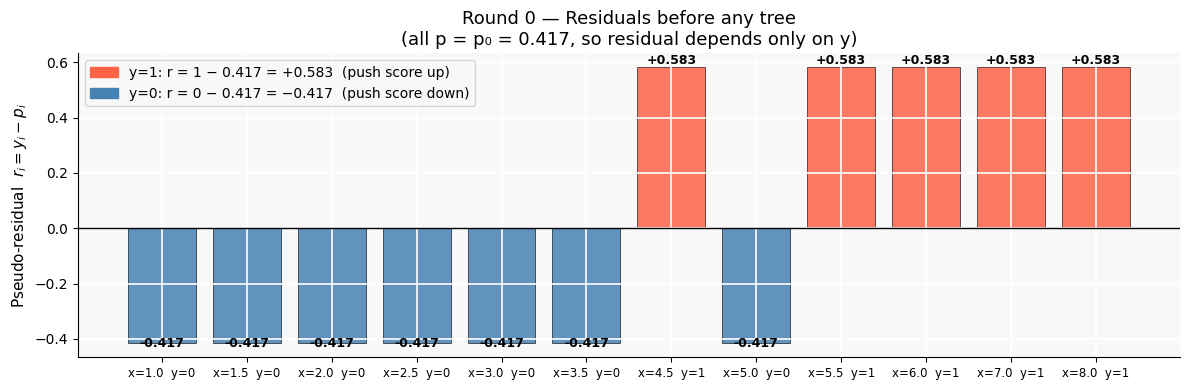

In [13]:
p_init = np.full(n, p0)
r_init = y - p_init

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = [C["cls1"] if ri > 0 else C["cls0"] for ri in r_init]
ax.bar(range(n), r_init, color=bar_colors, edgecolor="black", lw=0.5, alpha=0.85)
for i, (r, yi) in enumerate(zip(r_init, y)):
    ax.text(i, r + 0.012*np.sign(r), f"{r:+.3f}", ha="center", fontsize=9, fontweight="bold")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(n))
ax.set_xticklabels([f"x={xi[0]:.1f}  y={int(yi)}" for xi, yi in zip(X, y)], fontsize=8.5)
ax.set_ylabel(r"Pseudo-residual  $r_i = y_i - p_i$")
ax.set_title("Round 0 — Residuals before any tree\n"
             f"(all p = p₀ = {p0:.3f}, so residual depends only on y)")
ax.legend(handles=[
    mpatches.Patch(color=C["cls1"], label=f"y=1: r = 1 − {p0:.3f} = +{1-p0:.3f}  (push score up)"),
    mpatches.Patch(color=C["cls0"], label=f"y=0: r = 0 − {p0:.3f} = −{p0:.3f}  (push score down)"),
])
plt.tight_layout()
plt.show()

## 6 · The Leaf Value Formula — Newton's Method Inside Each Leaf

---

When a regression tree partitions the data, each leaf is assigned an output value $\gamma_\ell$.
We could use the mean residual in the leaf (what sklearn does by default for regression trees), but the correct step comes from a **2nd-order Taylor expansion** of log loss inside the leaf:

$$\gamma_\ell = \frac{\displaystyle\sum_{i \in \ell}(y_i - p_i)}{\displaystyle\sum_{i \in \ell} p_i(1 - p_i)}$$

- **Numerator** $\sum(y_i - p_i)$: the total gradient signal in this leaf (how much to shift)
- **Denominator** $\sum p_i(1-p_i)$: the total Hessian (curvature of log loss)

> **Analogy:** You are rolling a ball downhill. The gradient says *which direction* to roll; the Hessian says *how steep* the hill is. Dividing by the curvature gives the optimal step size — this is Newton's method applied leaf by leaf.

**Why does $p_i(1-p_i)$ appear?** It is the second derivative (variance) of the Bernoulli distribution — the curvature of log loss at $p_i$. Near $p=0.5$ it is maximised (0.25); near 0 or 1 it approaches 0. A leaf full of confident predictions has small curvature, so the same residual implies a *larger* logit update is needed to change the probability at all.


## 7 · Full Algorithm — From Scratch

---

The complete implementation is in the helpers cell above (`fit_gbc`). Here we run it on the 1-D dataset and see the per-round log-loss drop.


In [14]:
LR    = 0.5
DEPTH = 2
M     = 5

print(f"Training GBC: M={M} trees, ν={LR}, max_depth={DEPTH}\n")
F0_val, gbc_trees, history = fit_gbc(X, y, n_estimators=M,
                                      learning_rate=LR, max_depth=DEPTH)
print(f"\nF₀ (base-rate log-odds) = {F0_val:.4f}")
print(f"Final accuracy: {((predict_ensemble(F0_val, gbc_trees, X, LR) >= 0.5) == y.astype(bool)).mean():.3f}")

Training GBC: M=5 trees, ν=0.5, max_depth=2

Round  1  |  log-loss = 0.36575  |  acc = 0.917
Round  2  |  log-loss = 0.25417  |  acc = 0.917
Round  3  |  log-loss = 0.16780  |  acc = 1.000
Round  4  |  log-loss = 0.12444  |  acc = 1.000
Round  5  |  log-loss = 0.08996  |  acc = 1.000

F₀ (base-rate log-odds) = -0.3365
Final accuracy: 1.000


## 8 · Anatomy of Round 1 — Trace Every Sample by Hand

---

Before looking at plots, let's verify the leaf-value formula by tracing every sample through the first tree.


In [15]:
snap  = history[0]
p_vec = snap["p"]
r_vec = snap["residuals"]

print("=" * 74)
print("ROUND 1 — Per-sample table")
print("=" * 74)
print(f"{'i':>3}  {'x':>5}  {'y':>3}  {'p_i':>7}  {'r=y-p':>9}  {'leaf':>5}  {'γ_leaf':>9}  {'ν·γ':>8}")
print("-" * 74)
for i in range(n):
    leaf  = snap["leaf_ids"][i]
    gamma = snap["leaf_gamma"][leaf]
    print(f"{i:>3}  {X[i,0]:>5.1f}  {int(y[i]):>3}  {p_vec[i]:>7.4f}  "
          f"{r_vec[i]:>+9.4f}  {leaf:>5}  {gamma:>9.4f}  {LR*gamma:>+8.4f}")

print()
print("Leaf-level Newton step  (γ = Σ(y−p) / Σ p(1−p)):")
for leaf in np.unique(snap["leaf_ids"]):
    mask  = snap["leaf_ids"] == leaf
    xs    = X[mask].ravel()
    ys    = y[mask]
    ps    = p_vec[mask]
    g_sum = np.sum(ys - ps)
    h_sum = np.sum(ps * (1 - ps))
    g     = snap["leaf_gamma"][leaf]
    print(f"  Leaf {leaf}  x={xs}  y={ys.astype(int).tolist()}")
    print(f"    Σ(y−p) = {g_sum:+.4f}   Σp(1−p) = {h_sum:.4f}   γ = {g_sum:.4f}/{h_sum:.4f} = {g:.4f}")

ROUND 1 — Per-sample table
  i      x    y      p_i      r=y-p   leaf     γ_leaf       ν·γ
--------------------------------------------------------------------------
  0    1.0    0   0.4167    -0.4167      1    -1.7143   -0.8571
  1    1.5    0   0.4167    -0.4167      1    -1.7143   -0.8571
  2    2.0    0   0.4167    -0.4167      1    -1.7143   -0.8571
  3    2.5    0   0.4167    -0.4167      1    -1.7143   -0.8571
  4    3.0    0   0.4167    -0.4167      1    -1.7143   -0.8571
  5    3.5    0   0.4167    -0.4167      1    -1.7143   -0.8571
  6    4.5    1   0.4167    +0.5833      3     0.3429   +0.1714
  7    5.0    0   0.4167    -0.4167      3     0.3429   +0.1714
  8    5.5    1   0.4167    +0.5833      4     2.4000   +1.2000
  9    6.0    1   0.4167    +0.5833      4     2.4000   +1.2000
 10    7.0    1   0.4167    +0.5833      4     2.4000   +1.2000
 11    8.0    1   0.4167    +0.5833      4     2.4000   +1.2000

Leaf-level Newton step  (γ = Σ(y−p) / Σ p(1−p)):
  Leaf 1  x=[1. 

## 9 · Visual Tree Graphs — Rounds 1, 2, 3

---

For each round:
- **Left panel**: The regression tree fitted to the pseudo-residuals (`plot_tree`).
  Each leaf shows the mean residual that sklearn uses for splitting — the actual update applied to each sample is the Newton-step $\gamma$ shown in the table below the figure.
- **Right panel**: The 1-D data plotted on a number line.
  Points are coloured by their pseudo-residual value (red = positive, needs score pushed up; blue = negative, needs score pushed down).
  Vertical dashed lines mark the split thresholds. Labels show each sample's leaf assignment and $\gamma$ value.


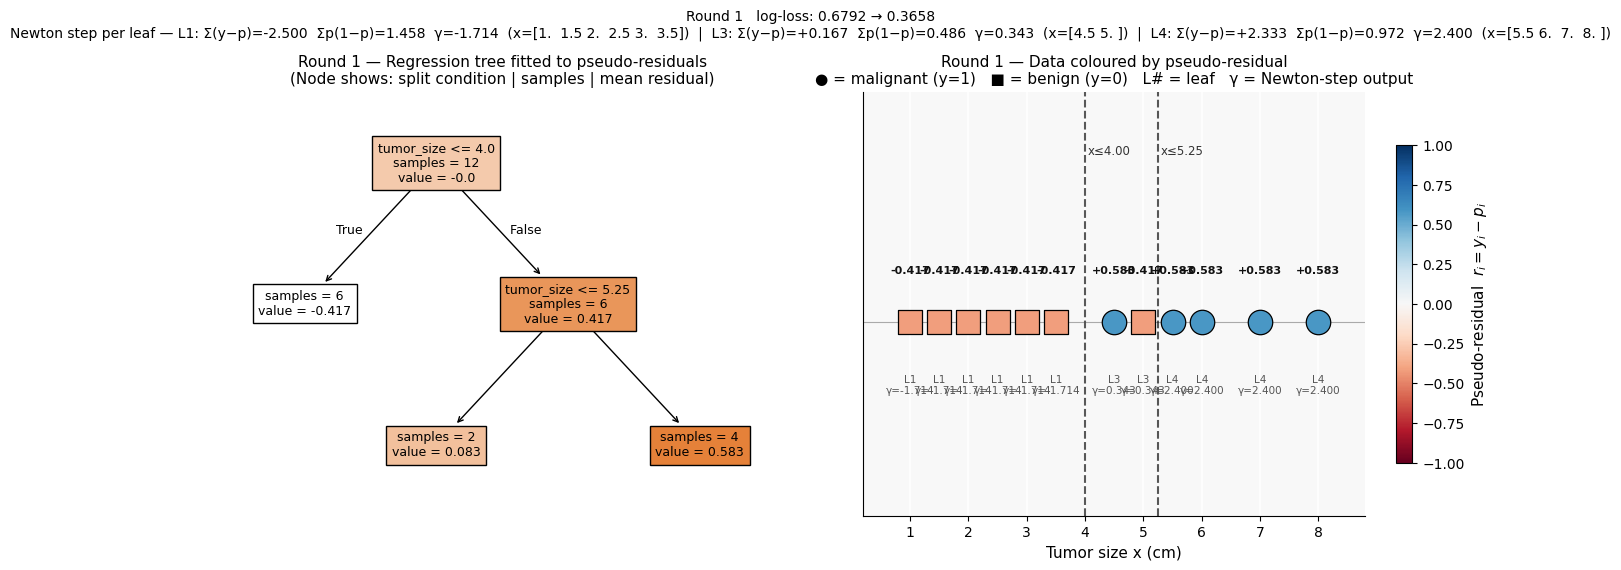

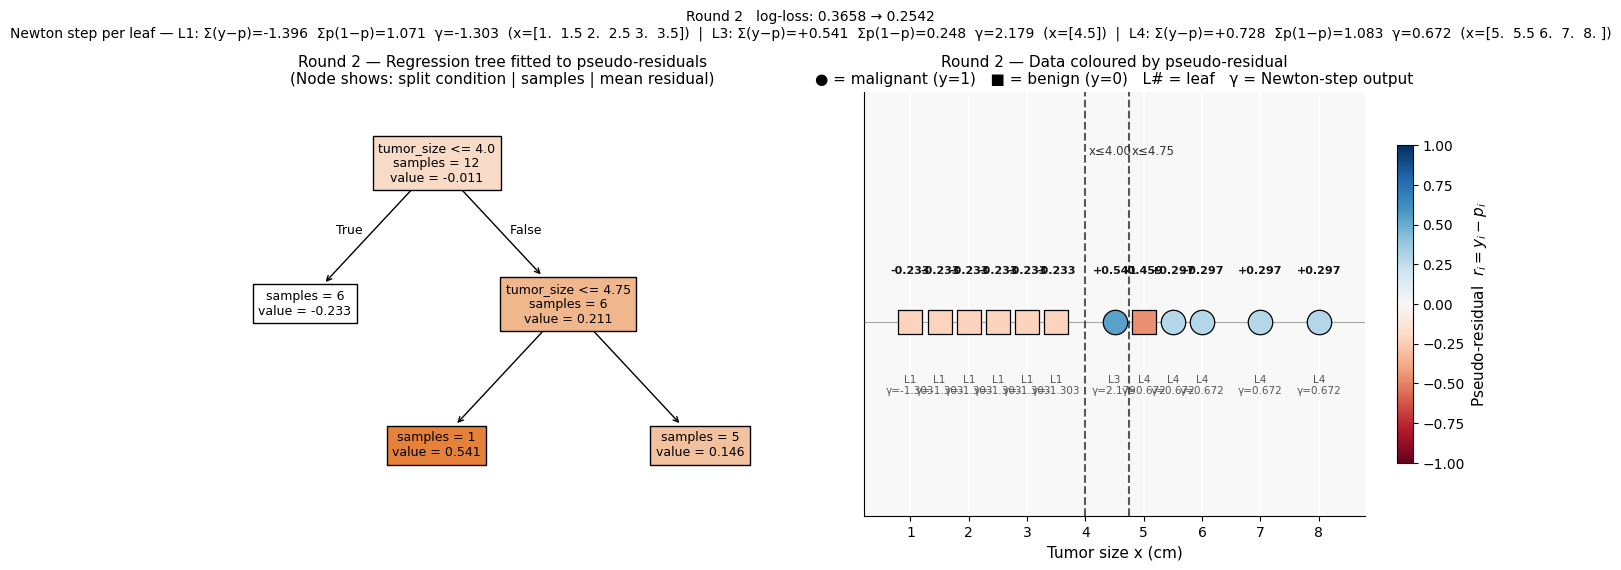

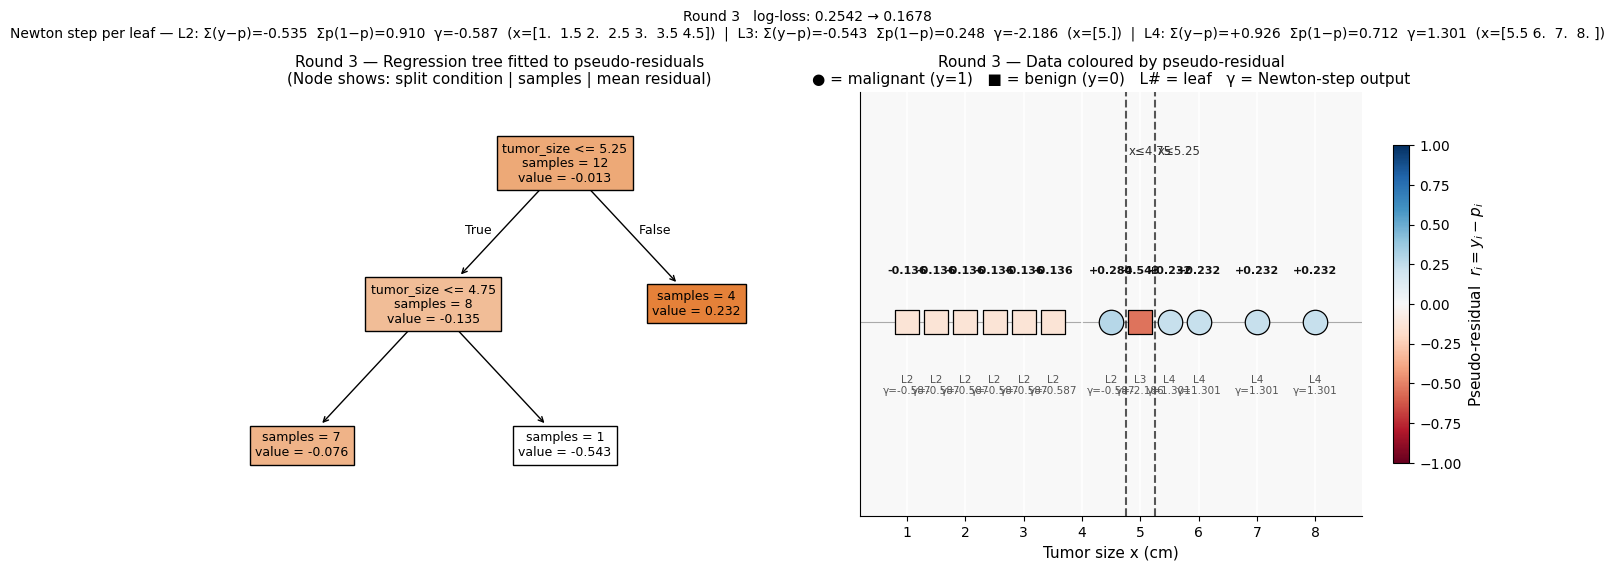

In [16]:
cmap_rb = plt.cm.RdBu
norm_rb = Normalize(vmin=-1, vmax=1)

for m in [1, 2, 3]:
    snap       = history[m - 1]
    tree       = snap["tree"]
    residuals  = snap["residuals"]
    leaf_ids   = snap["leaf_ids"]
    leaf_gamma = snap["leaf_gamma"]
    p_vec      = snap["p"]

    fig = plt.figure(figsize=(17, 5.5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1.05, 1.0], wspace=0.05)
    ax_tree = fig.add_subplot(gs[0])
    ax_data = fig.add_subplot(gs[1])

    # ── Left: sklearn tree diagram ────────────────────────────────────────────
    plot_tree(tree, feature_names=["tumor_size"], filled=True,
              ax=ax_tree, impurity=False, precision=3, fontsize=9)
    ax_tree.set_title(
        f"Round {m} — Regression tree fitted to pseudo-residuals\n"
        f"(Node shows: split condition | samples | mean residual)", fontsize=11)

    # ── Right: number-line scatter ────────────────────────────────────────────
    # split thresholds
    t = tree.tree_
    thresholds = sorted(set(t.threshold[t.threshold > -2]))
    for thr in thresholds:
        ax_data.axvline(thr, color="black", lw=1.5, ls="--", alpha=0.65, zorder=2)
        ax_data.text(thr + 0.05, 0.5, f"x≤{thr:.2f}", fontsize=8.5,
                     color="#333", va="top")

    # points
    for i, (xi, ri, yi, leaf) in enumerate(zip(X.ravel(), residuals, y, leaf_ids)):
        face  = cmap_rb(norm_rb(ri))
        shape = "o" if yi == 1 else "s"
        ax_data.scatter(xi, 0.0, s=310, marker=shape, color=face,
                        edgecolors="black", lw=0.9, zorder=4)
        gamma = leaf_gamma[leaf]
        # residual above
        ax_data.text(xi,  0.13, f"{ri:+.3f}", ha="center", va="bottom",
                     fontsize=8, color="#111", fontweight="bold")
        # leaf + gamma below
        ax_data.text(xi, -0.15, f"L{leaf}\nγ={gamma:.3f}",
                     ha="center", va="top", fontsize=7.5, color="#555")

    # colorbar
    sm = ScalarMappable(cmap=cmap_rb, norm=norm_rb)
    sm.set_array([])
    plt.colorbar(sm, ax=ax_data, label=r"Pseudo-residual  $r_i = y_i - p_i$", shrink=0.75)

    ax_data.set_xlim(0.2, 8.8)
    ax_data.set_ylim(-0.55, 0.65)
    ax_data.set_yticks([])
    ax_data.set_xlabel("Tumor size x (cm)")
    ax_data.set_title(
        f"Round {m} — Data coloured by pseudo-residual\n"
        f"● = malignant (y=1)   ■ = benign (y=0)   L# = leaf   γ = Newton-step output",
        fontsize=11)
    ax_data.axhline(0, color="#aaa", lw=0.8, zorder=1)

    # Newton-step table as figure text
    leaf_rows = []
    for leaf in np.unique(leaf_ids):
        mask  = leaf_ids == leaf
        g_sum = np.sum(y[mask] - p_vec[mask])
        h_sum = np.sum(p_vec[mask] * (1 - p_vec[mask]))
        gamma = leaf_gamma[leaf]
        xs    = X[mask].ravel()
        leaf_rows.append(f"L{leaf}: Σ(y−p)={g_sum:+.3f}  Σp(1−p)={h_sum:.3f}  γ={gamma:.3f}  (x={xs})")
    table_str = "  |  ".join(leaf_rows)

    prev_loss = history[m-2]["loss"] if m > 1 else log_loss_val(y, np.full(n, F0_val))
    plt.suptitle(
        f"Round {m}   log-loss: {prev_loss:.4f} → {snap['loss']:.4f}\n"
        f"Newton step per leaf — {table_str}",
        fontsize=10, y=1.03)
    plt.tight_layout()
    plt.show()
    print()

## 10 · How Residuals and Probabilities Evolve

---

Each boosting round shrinks the pseudo-residuals — the model has less to correct.
**Left**: Residual heatmap (sample × round). Darker red = model still too low; darker blue = model too high.
**Right**: Per-sample probability trajectory. By round 5 most samples are on the correct side of 0.5.


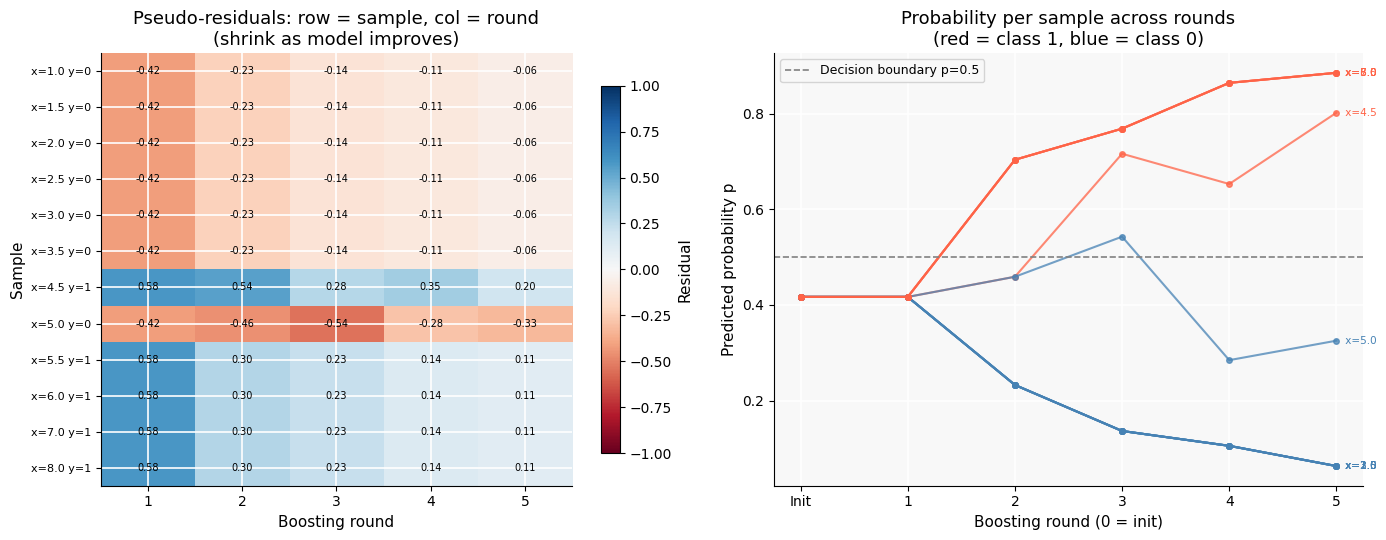

In [17]:
resid_mat = np.array([h["residuals"] for h in history])
prob_mat  = np.array([h["p"]          for h in history])
p_init_v  = np.full(n, sigmoid(F0_val))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Residual heatmap ──────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(resid_mat.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("Boosting round")
ax.set_ylabel("Sample")
ax.set_title("Pseudo-residuals: row = sample, col = round\n(shrink as model improves)")
ax.set_xticks(range(M))
ax.set_xticklabels([str(h["round"]) for h in history])
ax.set_yticks(range(n))
ax.set_yticklabels([f"x={xi[0]:.1f} y={int(yi)}" for xi, yi in zip(X, y)], fontsize=8)
plt.colorbar(im, ax=ax, label="Residual", shrink=0.85)
for row in range(n):
    for col in range(M):
        v = resid_mat[col, row]
        ax.text(col, row, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="black" if abs(v) < 0.6 else "white")

# ── Probability trajectories ──────────────────────────────────────────────────
ax2 = axes[1]
for i in range(n):
    color = C["cls1"] if y[i] == 1 else C["cls0"]
    probs = np.concatenate([[p_init_v[i]], prob_mat[:, i]])
    ax2.plot(range(M + 1), probs, "o-", color=color, alpha=0.75, lw=1.5, ms=4)
    ax2.text(M + 0.05, probs[-1], f" x={X[i,0]:.1f}", fontsize=7.5, va="center", color=color)

ax2.axhline(0.5, color="grey", ls="--", lw=1.2, label="Decision boundary p=0.5")
ax2.set_xlabel("Boosting round (0 = init)")
ax2.set_ylabel("Predicted probability p")
ax2.set_title("Probability per sample across rounds\n(red = class 1, blue = class 0)")
ax2.set_xticks(range(M + 1))
ax2.set_xticklabels(["Init"] + [str(h["round"]) for h in history])
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11 · Loss Curve

---

Each tree reduces log loss. The steepest drop is at round 1 — early trees capture the dominant signal. Later rounds chase diminishing residuals.


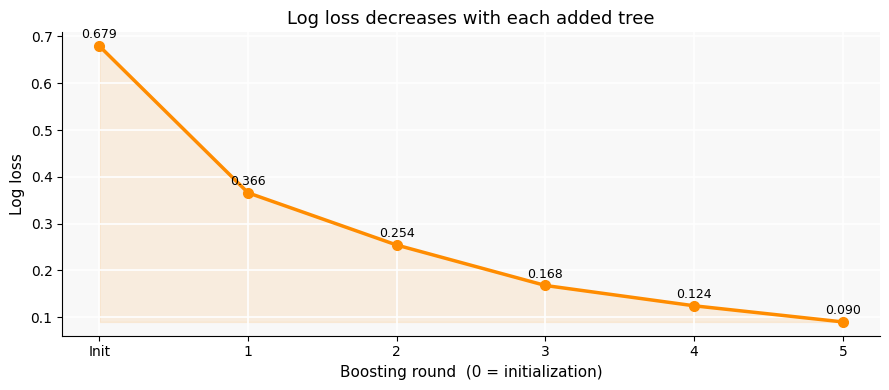

Reduction: 0.67919 → 0.08996  (86.8%)


In [18]:
init_loss = log_loss_val(y, np.full(n, F0_val))
losses    = [init_loss] + [h["loss"] for h in history]
rounds    = list(range(len(losses)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rounds, losses, "o-", color=C["logodds"], lw=2.5, ms=7, zorder=3)
for r, l in zip(rounds, losses):
    ax.text(r, l + 0.01, f"{l:.3f}", ha="center", va="bottom", fontsize=9)
ax.fill_between(rounds, losses, losses[-1], alpha=0.1, color=C["logodds"])
ax.set_xlabel("Boosting round  (0 = initialization)")
ax.set_ylabel("Log loss")
ax.set_title("Log loss decreases with each added tree")
ax.set_xticks(rounds)
ax.set_xticklabels(["Init"] + [str(m+1) for m in range(M)])
plt.tight_layout()
plt.show()
print(f"Reduction: {losses[0]:.5f} → {losses[-1]:.5f}  ({100*(losses[0]-losses[-1])/losses[0]:.1f}%)")

## 12 · Decision Boundary Evolution — 2-D Dataset

---

Switching to a 2-D dataset to visualise the probability surface.
Each panel shows the model at a different boosting round. The black contour is the $p=0.5$ decision boundary.


Training on 2-D dataset...
Done.


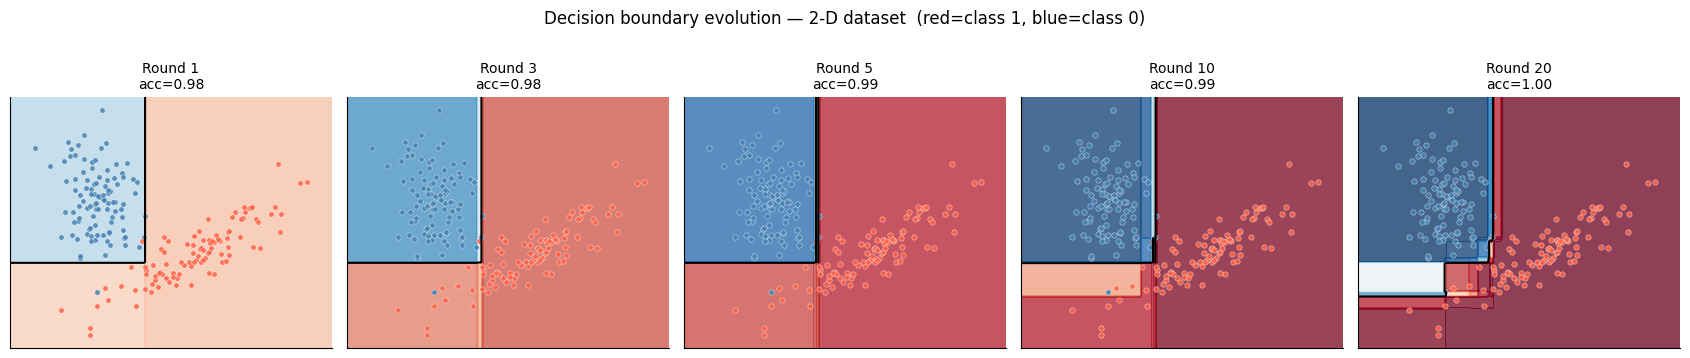

In [19]:
# 2-D dataset
X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_informative=2, n_clusters_per_class=1,
                              class_sep=1.0, random_state=7)
y2 = y2.astype(float)

LR2 = 0.3
print("Training on 2-D dataset...")
F0_2d, trees_2d, _ = fit_gbc(X2, y2, n_estimators=20, learning_rate=LR2,
                               max_depth=2, verbose=False)
print("Done.")

# Grid
x1l, x1h = X2[:,0].min()-0.5, X2[:,0].max()+0.5
x2l, x2h = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx1, xx2  = np.meshgrid(np.linspace(x1l, x1h, 150), np.linspace(x2l, x2h, 150))
Xg = np.c_[xx1.ravel(), xx2.ravel()]

show_at = [1, 3, 5, 10, 20]
fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))

for ax, m in zip(axes, show_at):
    Z = predict_ensemble(F0_2d, trees_2d[:m], Xg, LR2).reshape(xx1.shape)
    ax.contourf(xx1, xx2, Z, levels=50, cmap="RdBu_r", alpha=0.75, vmin=0, vmax=1)
    ax.contour( xx1, xx2, Z, levels=[0.5], colors="black", linewidths=1.5)
    ax.scatter(X2[y2==0,0], X2[y2==0,1], s=15, color=C["cls0"],
               edgecolors="white", lw=0.3, alpha=0.85)
    ax.scatter(X2[y2==1,0], X2[y2==1,1], s=15, color=C["cls1"],
               edgecolors="white", lw=0.3, alpha=0.85)
    acc = ((predict_ensemble(F0_2d, trees_2d[:m], X2, LR2) >= 0.5) == y2.astype(bool)).mean()
    ax.set_title(f"Round {m}\nacc={acc:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Decision boundary evolution — 2-D dataset  (red=class 1, blue=class 0)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 13 · Effect of Learning Rate $\nu$ — Shrinkage as Regularisation

---

The learning rate $\nu$ controls how much each tree contributes to the ensemble.
- **Large $\nu$**: fast convergence on training data, but risks overfitting
- **Small $\nu$**: needs more trees to reach the same loss, but generalises better

> **Rule of thumb:** Use $\nu \leq 0.1$ and compensate with more trees.
> The final loss is the same — the path there just has more, smaller steps.


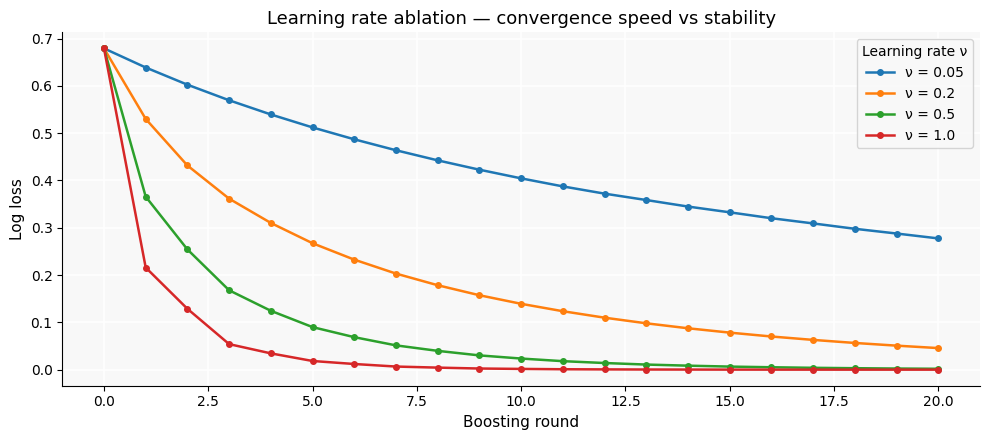

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.5))

for lr_test in [0.05, 0.2, 0.5, 1.0]:
    F0t, _, hist_t = fit_gbc(X, y, n_estimators=20, learning_rate=lr_test,
                              max_depth=2, verbose=False)
    init_l = log_loss_val(y, np.full(n, F0t))
    curve  = [init_l] + [h["loss"] for h in hist_t]
    ax.plot(range(len(curve)), curve, "o-", lw=1.8, ms=4, label=f"ν = {lr_test}")

ax.set_xlabel("Boosting round")
ax.set_ylabel("Log loss")
ax.set_title("Learning rate ablation — convergence speed vs stability")
ax.legend(title="Learning rate ν", fontsize=10)
plt.tight_layout()
plt.show()

## 14 · Interactive Widget — Explore Trees × Learning Rate

---

Drag the sliders to see how the number of trees and learning rate jointly control the fitted curve.


In [21]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    def plot_interactive(n_trees, learning_rate):
        F0w, tw, _ = fit_gbc(X, y, n_estimators=n_trees,
                              learning_rate=learning_rate, max_depth=2, verbose=False)
        x_plot = np.linspace(0.3, 8.7, 400).reshape(-1, 1)
        p_plot = predict_ensemble(F0w, tw, x_plot, learning_rate)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        ax = axes[0]
        ax.plot(x_plot.ravel(), p_plot, color=C["pred"], lw=2.5, label="P(malignant)")
        ax.axhline(0.5, color="grey", ls="--", lw=1.2, label="Decision boundary")
        for xi, yi in zip(X.ravel(), y):
            ax.scatter(xi, yi, s=120, color=(C["cls1"] if yi else C["cls0"]),
                       zorder=3, edgecolors="black", lw=0.7)
        ax.set_xlabel("Tumor size x"); ax.set_ylabel("P(malignant)")
        acc = ((predict_ensemble(F0w, tw, X, learning_rate) >= 0.5) == y.astype(bool)).mean()
        ax.set_title(f"M={n_trees} trees, ν={learning_rate:.2f}  |  acc={acc:.3f}")
        ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9)

        ax2 = axes[1]
        init_l = log_loss_val(y, np.full(n, F0w))
        _, _, hist_w = fit_gbc(X, y, n_estimators=n_trees,
                                learning_rate=learning_rate, max_depth=2, verbose=False)
        curve = [init_l] + [h["loss"] for h in hist_w]
        ax2.plot(range(len(curve)), curve, "o-", color=C["logodds"], lw=2, ms=5)
        ax2.set_xlabel("Round"); ax2.set_ylabel("Log loss")
        ax2.set_title("Loss curve")
        plt.tight_layout(); plt.show()

    widgets.interact(
        plot_interactive,
        n_trees=widgets.IntSlider(value=3, min=1, max=15, step=1, description="Trees M:"),
        learning_rate=widgets.FloatSlider(value=0.5, min=0.05, max=1.5, step=0.05, description="LR ν:"),
    )
except ImportError:
    print("ipywidgets not installed — showing static version")
    fig, ax = plt.subplots(figsize=(10, 4))
    for lrv in [0.2, 0.5, 1.0]:
        x_plot = np.linspace(0.3, 8.7, 400).reshape(-1, 1)
        F0s, ts, _ = fit_gbc(X, y, n_estimators=5, learning_rate=lrv, max_depth=2, verbose=False)
        ax.plot(x_plot.ravel(), predict_ensemble(F0s, ts, x_plot, lrv), lw=2, label=f"ν={lrv}")
    for xi, yi in zip(X.ravel(), y):
        ax.scatter(xi, yi, s=100, color=(C["cls1"] if yi else C["cls0"]),
                   zorder=3, edgecolors="black", lw=0.6)
    ax.axhline(0.5, ls="--", color="grey")
    ax.set_xlabel("x"); ax.set_ylabel("P(class 1)")
    ax.set_title("Effect of learning rate (5 trees)")
    ax.legend(); plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=3, description='Trees M:', max=15, min=1), FloatSlider(value=0.5, descri…

## 15 · Two Framings to Hold Simultaneously

---

### Friedman's MART View (Gradient Descent in Function Space)
Each tree approximates the **negative functional gradient** — the direction of steepest descent on the loss surface in $\mathbb{R}^n$.
You're doing gradient descent, but the "parameters" being optimised are the prediction values $F(x_1), \ldots, F(x_n)$.

### XGBoost View (Direct Loss Optimisation)
Skip the gradient-fitting indirection. At each split, directly minimise a **2nd-order Taylor expansion** of the loss using both $(g_i, h_i)$ to choose splits *and* to set leaf values.
The leaf formula $\gamma = \sum g_i / \sum h_i$ falls straight out of the Newton step.

| | MART (Friedman) | XGBoost |
|-|---|---|
| Tree predicts | Mean residual $y - p$ | Splits chosen via $g, h$ score |
| Leaf values | Newton step $\gamma = \sum(y-p)/\sum p(1-p)$ | Same formula, directly derived |
| Split criterion | Variance of residuals | Score: $(\sum g)^2 / (\sum h + \lambda)$ |
| Regularisation | Shrinkage $\nu$ | Shrinkage + L1/L2 on leaf values |

Both give the same predictions — XGBoost simply integrates the Newton step into split selection too.

### Multiclass Extension

Keep $K$ scores $F_k(x)$ per sample (one per class), map through **softmax** instead of sigmoid, and fit one tree per class per round against residuals $r_{ik} = y_{ik} - p_{ik}$.


## 16 · Summary

---

| Concept | Key Idea |
|---------|----------|
| Log-odds space | Predict $F(x) \in (-\infty, +\infty)$; map to probability via sigmoid |
| Log loss gradient | $\partial\mathcal{L}/\partial F = p - y$, so negative gradient = $y - p$ |
| Pseudo-residuals | $r_i = y_i - p_i$ — how wrong you are, in probability units |
| Regression trees for classification | Trees fit a *continuous* residual target; classification emerges from the ensemble |
| Newton-step leaf values | $\gamma = \sum(y-p)/\sum p(1-p)$ — divides by loss curvature for optimal step |
| Learning rate $\nu$ | Shrinkage: smaller steps → more trees needed → better generalisation |
| Initialization $F_0$ | Log-odds of class balance — best constant prediction |
| MART vs XGBoost | Same math; XGBoost integrates gradient + curvature into split criterion too |
| Multiclass | $K$ scores + softmax; one tree per class per round |

> **The elegant collapse:** Despite producing a binary classifier, all the heavy lifting is done by tiny *regression* trees fitting a *continuous* residual target. Classification is a label slapped on top of a sequence of regression corrections in log-odds space.
